In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

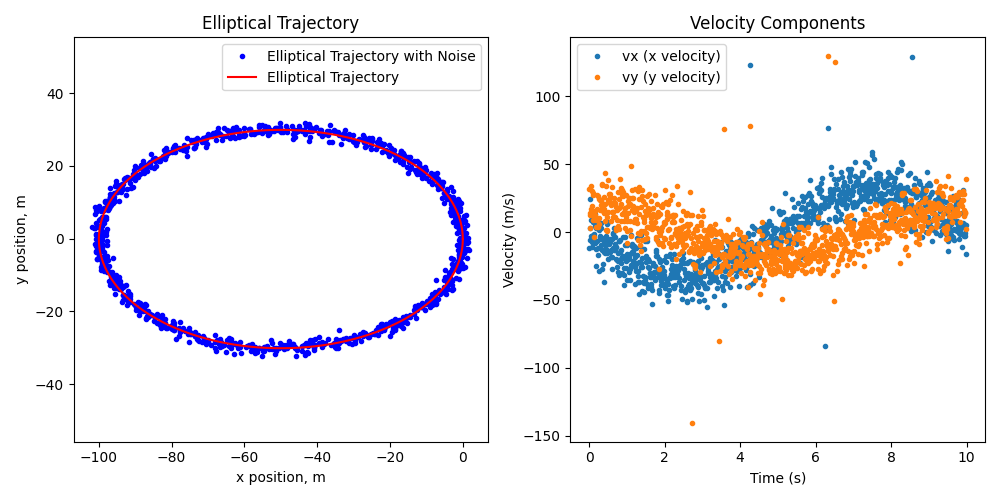

In [2]:
data = pd.read_csv('data/kf_2d_data.csv')

ts = data['ts'].values
posx_gt = data['posx_gt'].values
posy_gt = data['posy_gt'].values
velx = data['velx'].values  
vely = data['vely'].values
posx_meas = data['posx_meas'].values
posy_meas = data['posy_meas'].values
N = len(ts)

# Plot the results
plt.figure(figsize=(10, 5))

# Plot position
plt.subplot(1, 2, 1)
plt.plot(posx_meas, posy_meas, 'b.', label="Elliptical Trajectory with Noise")
plt.plot(posx_gt, posy_gt, 'r', label="Elliptical Trajectory")
plt.xlabel("x position, m")
plt.ylabel("y position, m")
plt.title("Elliptical Trajectory")
plt.axis('equal')
plt.legend()

# Plot velocity
plt.subplot(1, 2, 2)
plt.plot(ts, velx, '.', label="vx (x velocity)")
plt.plot(ts, vely, '.', label="vy (y velocity)")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity Components")
plt.legend()

plt.tight_layout()

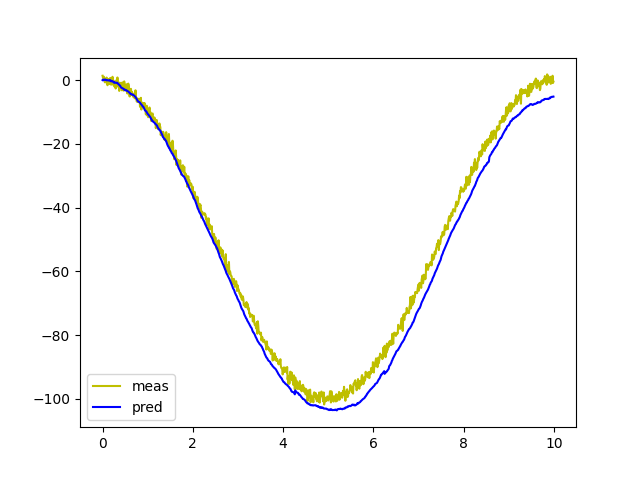

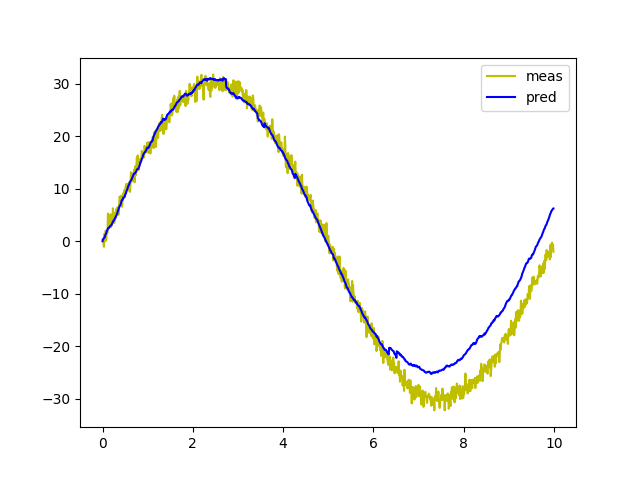

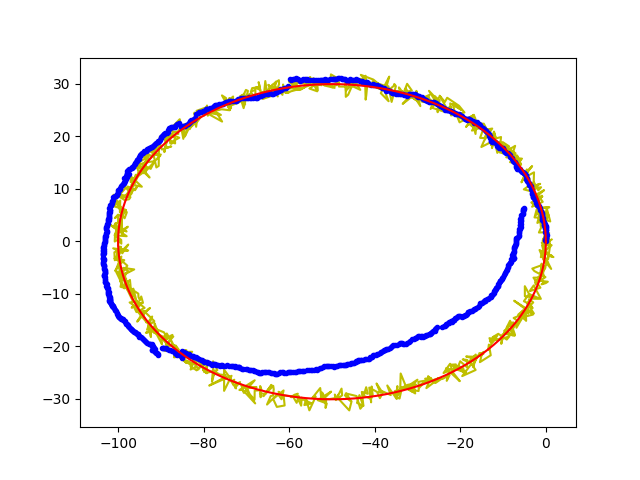

In [3]:
pred_posx = np.zeros(N)
pred_posy = np.zeros(N)
for i in range(N-1):
    dt = ts[i+1] - ts[i]
    pred_posx[i+1] = pred_posx[i] + velx[i]*dt
    pred_posy[i+1] = pred_posy[i] + vely[i]*dt

plt.figure()
plt.plot(ts, posx_meas, 'y', label='meas')
plt.plot(ts, pred_posx, 'b', label='pred')
plt.legend()

plt.figure()
plt.plot(ts, posy_meas, 'y', label='meas')
plt.plot(ts, pred_posy, 'b', label='pred')
plt.legend()

plt.figure()
plt.plot(posx_meas, posy_meas, 'y', label='meas')
plt.plot(pred_posx, pred_posy, 'b.', label='pred')
plt.plot(posx_gt, posy_gt, 'r')

In [4]:
A = np.zeros((4,4))
A[0,2] = 1
A[1,3] = 1
B = np.zeros((4,4))
B[0,0] = 1
B[1,0] = 1 

H = np.eye(4)

Q = np.eye(4)*10**-2 # process noise
# Q[0, 0] = 10**-100
# Q[1, 1] = 10**-100

R = np.eye(4)*10**-1.25 # measurement noise
R[2,2] = 10**-100
R[3,3] = 10**-100

# print(f"A=\n{A}")
#print(f"H=\n{H}")
# print(f"Q=\n{Q}")
# print(f"R=\n{R}")

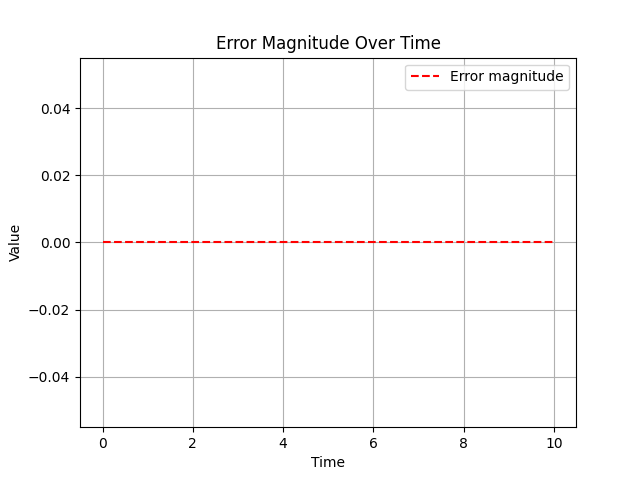

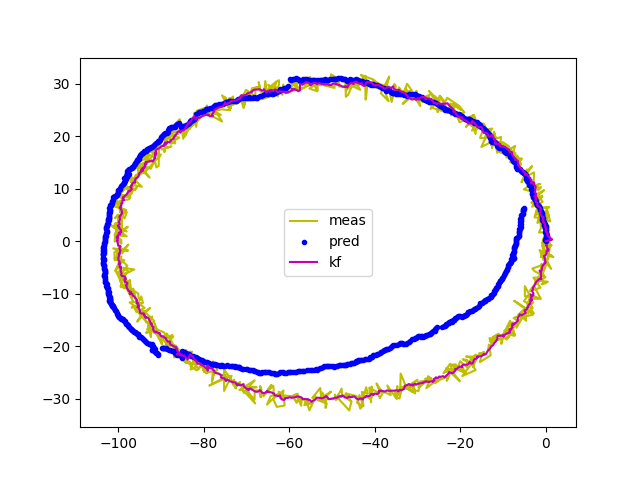

In [5]:

states = np.zeros((N,4)) # x, y, vx, vy
P = np.eye(4)*10**10 # initial covariance - large
error_mag = np.zeros(N)  # Magnitude of z
for i in range(N-1):
    states_now = states[i, None].T
    dt = ts[i+1] - ts[i]

    # get current velocity, keep the position
    Bu = np.array([[velx[i], vely[i], 0, 0]]).T
    #print((B@u).shape)

    # ===================================================
    # Prediction Step  (integration of the vel)
    # position prediction based on velocity
    states_pred = states_now + (A @ states_now + Bu)*dt
    # covariance prediction
    P_pred = A @ P @ A.T + Q
    # ===================================================

    # ===================================================
    # get current measurement
    z = np.array([[posx_meas[i], posy_meas[i], 0, 0]]).T    
    error = z - (H @ states_pred)
    #error_mag[i] = np.linalg.norm(error)
    # ===================================================

    # ===================================================
    # correction
    # kalman gain and error calculation
    K = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)    
    states_corr = states_pred + K @ error
    P_corr = (np.eye(4) - K @ H) @ P_pred
    # ===================================================

    # ===================================================
    # update states and P for the next iteration
    states[i+1] = np.reshape(states_corr, (4,))
    P = P_corr
    # ===================================================

posx_kf = states[:,0]
posy_kf = states[:,1]

plt.figure()
plt.plot(posx_meas, posy_meas, 'y', label='meas')
plt.plot(pred_posx, pred_posy, 'b.', label='pred')
plt.plot(posx_kf, posy_kf, 'm', label='kf')
#plt.plot(posx_gt, posy_gt, 'r', label='gt')
plt.legend()


# Plot the covariance and measurement magnitudes
plt.figure()
plt.plot(ts, error_mag, label="Error magnitude", color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.title("Error Magnitude Over Time")
plt.grid()
plt.show()




